# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 22    |  |
| :-------------|:-------------|
| Wouter Zeilmaker| 6585043 |
| Arie Klok| 6548350|

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

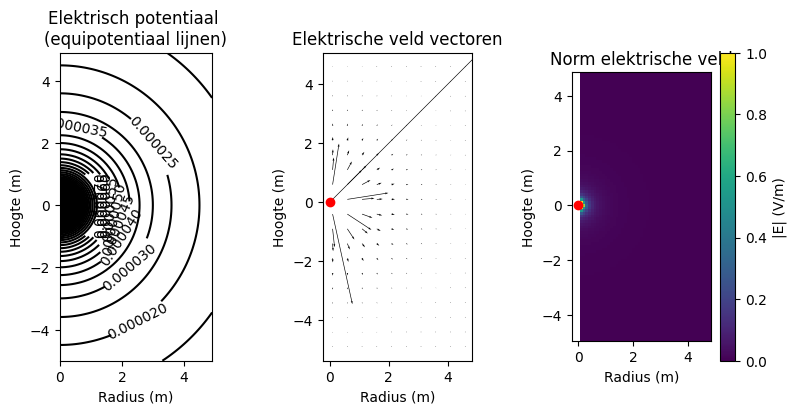

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Index voor z=0 is: 50

--- Resultaten ---
De berekende exponent uit de fit is: -1.000
Verwachte theoretische waarde: -1.000


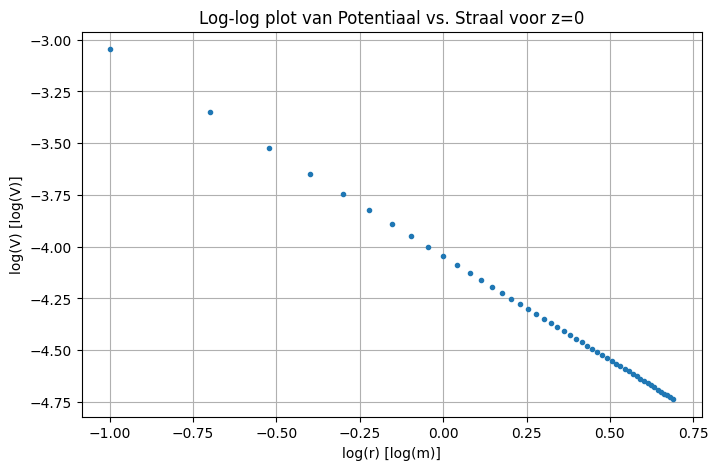

In [3]:
# 1. Bepaal welke index correspondeert met z = 0 m.

index_z0 = np.argmin(np.abs(z))
print(f"Index voor z=0 is: {index_z0}")

# 2. Plot de log van het potentiaal tegen de log van de straal.
r_lijn = r[1:] 
V_lijn = V[index_z0, 1:]  # potentiaal langs de lijn z=0, startend vanaf r=0.1 m (om singulariteit te vermijden)

# Bereken de logaritmes (basis 10)
log_r = np.log10(r_lijn)
log_V = np.log10(V_lijn)

# Maak de plot
plt.figure(figsize=(8, 5))
plt.plot(log_r, log_V, marker='.', linestyle='none', label='Data punten')
plt.xlabel('log(r) [log(m)]')
plt.ylabel('log(V) [log(V)]')
plt.title('Log-log plot van Potentiaal vs. Straal voor z=0')
plt.grid(True)

# 3. Fit de log van het potentiaal met de log van de straal.
# np.polyfit zoekt de beste rechte lijn (polynoom graad 1) door de log-log data.
# fit_result is een array met 2 waarden: [helling, y-snijpunt]
fit_result = np.polyfit(log_r, log_V, 1)

# 4. Print het exponent op een nette manier.
# De helling van de lijn is de gezochte exponent.
exponent = fit_result[0]

print() 
print(f"--- Resultaten ---")
print(f"De berekende exponent uit de fit is: {exponent:.3f}")
print(f"Verwachte theoretische waarde: -1.000")
plt.show()
#Volgens de wet van Coulomb is de elektrische potentiaal $V$ van een puntlading omgekeerd evenredig met de afstand $r$, 
# wat we schrijven als het machtsverband $V \propto r^{-1}$. 
# Door van beide variabelen de logaritme te nemen, 
# transformeren we dit kromme verband naar een lineaire vergelijking van de vorm $y = ax + b$. 
# In deze "log-log" weergave is de exponent van de straal (de $-1$) direct gelijk aan de helling ($a$) van de resulterende rechte lijn. 
# Met de functie np.polyfit berekenen we de best passende lijn door de simulatiedata, 
# waarbij de eerste waarde van de output de numerieke helling is. 
# Een resultaat van circa $-1.0$ bevestigt hiermee dat de potentiaal in het model inderdaad correct afneemt met de afstand.

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

RESULTAAT ELEKTRISCH VELD
De gevonden exponent is: -2.0404
Theoretische verwachting: -2.0000


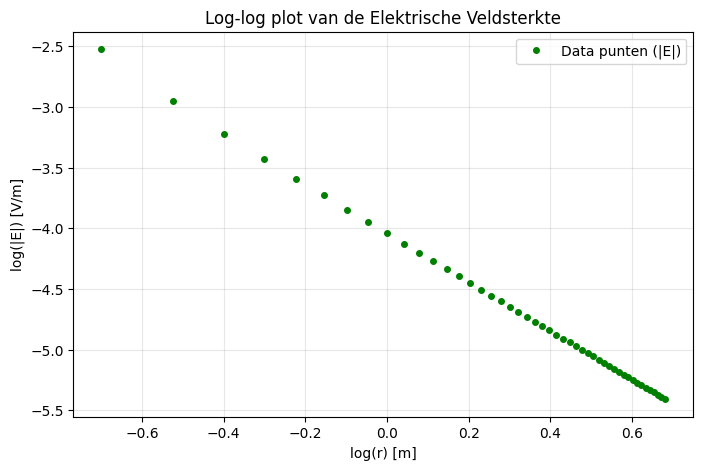

In [4]:
# --- STAP 1 (Achter de schermen nodig) ---
idx_z0_E = np.argmin(np.abs(z_for_E))

# --- STAP 2: Plot de log van het veld tegen de log van de straal ---
# We gebruiken r_for_E en normE. 
# We snijden bij BEIDE het eerste element weg ([1:]) om r=0 (en log(0)) te vermijden.
log_r_E = np.log10(r_for_E[1:])
log_E = np.log10(normE[idx_z0_E, 1:])

plt.figure(figsize=(8, 5))
plt.plot(log_r_E, log_E, 'go', label='Data punten (|E|)', markersize=4)
plt.xlabel('log(r) [m]')
plt.ylabel('log(|E|) [V/m]')
plt.title('Log-log plot van de Elektrische Veldsterkte')
plt.grid(True, alpha=0.3)

# --- STAP 3: Fit de log van het veld met de log van de straal ---
# We fitten een 1e-graads polynoom (rechte lijn: y = ax + b)
fit_E = np.polyfit(log_r_E, log_E, 1)
exponent_E = fit_E[0]



plt.legend()

# STAP 4: Print het exponent 
print("="*35)
print(f"RESULTAAT ELEKTRISCH VELD")
print(f"De gevonden exponent is: {exponent_E:.4f}")
print(f"Theoretische verwachting: -2.0000")
print("="*35)

plt.show()
#Het elektrisch veld (E) van een puntlading neemt af met het kwadraat van de afstand volgens de wet van Coulomb: E ∝ r⁻².
#Door de logaritme van zowel de straal als de veldsterkte te nemen, ontstaat een lineair verband met een theoretische helling van -2.
#Omdat de numerieke berekening de randen van het grid niet kan bepalen, gebruiken we de aangepaste arrays r_for_E en z_for_E.
#Met np.polyfit berekenen we de helling van de best passende lijn door deze log-log data om de numerieke exponent te bepalen.
#Een resultaat nabij de -2.00 bevestigt dat de simulatie de kwadratische afname van het elektrisch veld natuurkundig correct weergeeft.
# De 'centered finite-difference method' berekent de helling van het veld op basis van de omliggende gridpunten, waardoor de waarden op de uiterste randen niet bepaald kunnen worden.
#Om deze reden gebruiken we de ingekorte arrays 'r_for_E' en 'z_for_E', zodat de coördinaten-assen exact overeenkomen met de gereduceerde afmetingen van de berekende veld-matrix 'normE'.
# laatste is ff handig om die dingen over finite te weten, anders snap je niet waarom we die dingen doen.

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 1  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

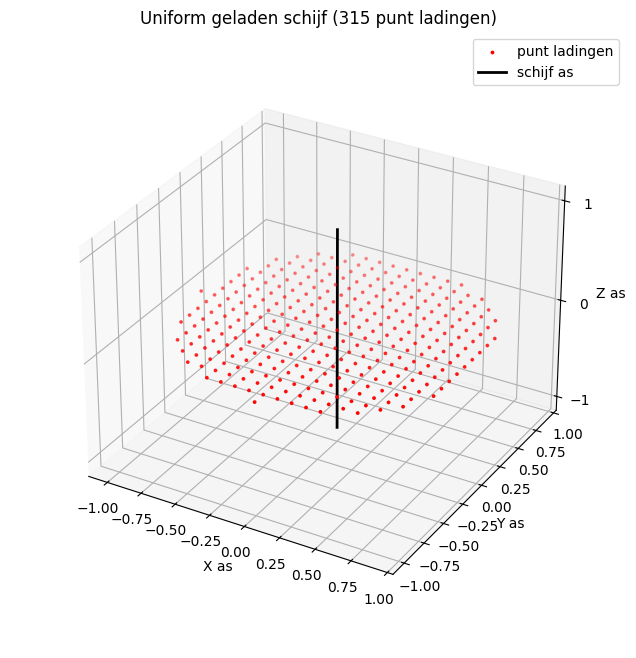

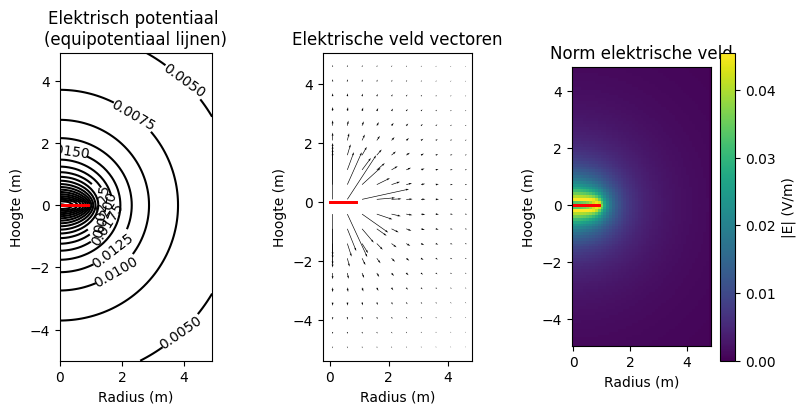

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat? 
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie? 
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

*Edit deze markdown cel met je antwoorden op vraag 2a.*
1. De disk radius is hoe ingezoomd je bent op de disk. En als je naar 0 gaat dan zie je dat het een puntlading word (je zoomt helemaal in).
2. De grid_step bepaalt de ruimtelijke resolutie van het rekenmodel en werkt als de afstand tussen de meetpunten in je grid. Waarbij een kleinere stapgrootte de nauwkeurigheid van de simulatie verhoogt, omdat de computer de helling van de potentiaal over een kortere afstand nauwkeuriger kan berekenen. een nadeel hiervan is dat de rekentijd kwadratisch toeneemt (het is 2d), aangezien een nauwkeurigere grid veel meer datapunten bevat die de computer moet verwerken en het dus veel lanber duurt.
3. z_coord_disk verandert de hoogte van de schijf. hiebij veranderen dingen zoals de veldsterkte en totale lading niet. Door de waarde aan te passen verplaatst het voorwerp naar boven of naar beneden en hierbij verandert het elektrische veldt gelijk mee. Zoals te zien is in de grafieken van de equipotentiaal lijnen, elektische veld vectoren en de norm van het elektrische veld.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
# Bereken het oppervlak van de schijf
surface_area = np.pi * (disk_radius**2)

# Bereken de totale lading op de schijf
total_charge = number_point_charges_on_disk * charge_one_point

# Bereken de ladingsdichtheid (sigma)
sigma = total_charge / surface_area

print(f"De ladingsdichtheid sigma is: {sigma:.4e} C/m^2")
# De ladingsdichtheid (sigma) van een schijf wordt berekend door de totale lading op de schijf te delen door het oppervlak van de schijf.

De ladingsdichtheid sigma is: 1.0027e-12 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

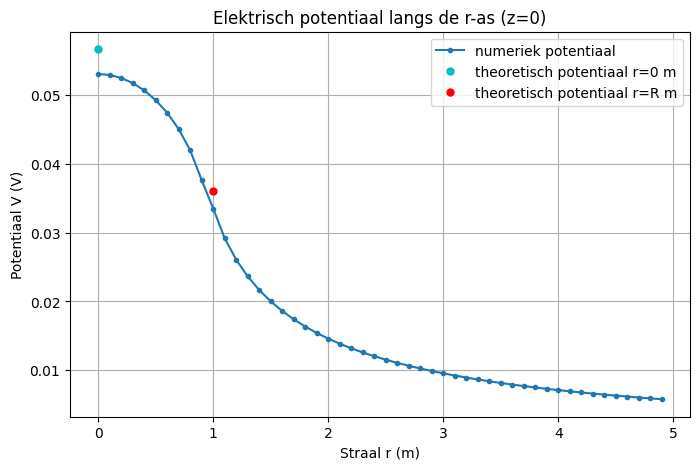

In [8]:

import scipy.constants as const

# 1. Bepaal de index waar de z-as 0 is
idx_z_zero = np.argmin(np.abs(z))

# Haal de vacuümpermittiviteit (epsilon_0) op zet het in een constante
eps0 = const.epsilon_0

# 2. Bereken de theoretische potentialen volgens de formules
V_0 = (sigma * disk_radius) / (2 * eps0)
V_R = (sigma * disk_radius) / (np.pi * eps0)
r_R = disk_radius

# 3. Plotten van de resultaten
plt.figure(figsize=(8, 5))
plt.title("Elektrisch potentiaal langs de r-as (z=0)")


plt.plot(r, V[idx_z_zero, :], "o-", label="numeriek potentiaal", markersize=3)

# De theoretische waardes toevoegen
plt.plot(0, V_0, "c.", label="theoretisch potentiaal r=0 m", markersize=10)
plt.plot(r_R, V_R, "r.", label="theoretisch potentiaal r=R m", markersize=10)

plt.legend()
plt.xlabel("Straal r (m)")
plt.ylabel("Potentiaal V (V)")
plt.grid(True)
plt.show()

# Je hebt twee verschillende formules voor het potentiaal van een schijf eentje waar je kijkt vanuit het midden en een andere vanaf de rand 
# Die vanaf de rand is altijd lager aangezien je over het algemeneen gemiddeld verder bent van de ladingen.
# In de formule zie je ook dat de potentiaal kleiner is door di pi in de noemer.

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


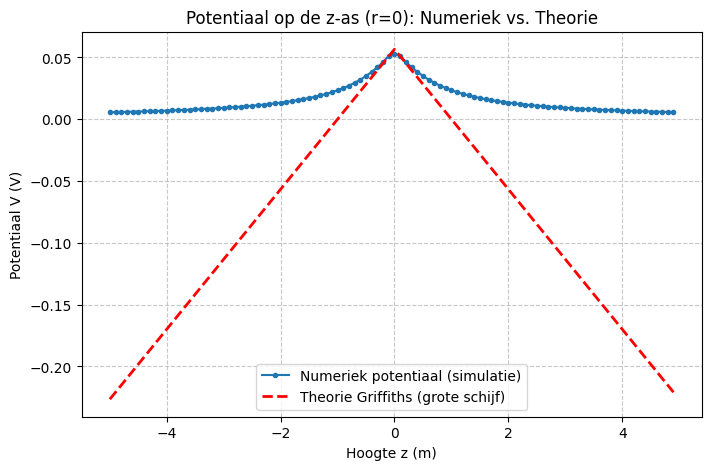

In [9]:

# 1. Bepaal de index waar de r-as 0 is (het centrum van de schijf)
# We zoeken de kolom in de V-matrix die overeenkomt met r = 0.
idx_r_zero = np.argmin(np.abs(r))

# 2. Bereken het theoretische potentiaal op de z-as volgens Griffiths (R >> z)
# De formule is V = (sigma / (2 * eps0)) * (R - |z|)
# We gebruiken np.abs(z) voor de absolute waarde van z.
eps0 = const.epsilon_0
V_theo_z = (sigma / (2 * eps0)) * (disk_radius - np.abs(z))

# 3. Plotten van de resultaten
plt.figure(figsize=(8, 5))
plt.title("Potentiaal op de z-as (r=0): Numeriek vs. Theorie")

# Plot de numerieke data: we selecteren alle z-waarden voor de kolom r=0
# V[:, idx_r_zero] betekent: neem alle rijen (z) van kolom idx_r_zero (r=0)
plt.plot(z, V[:, idx_r_zero], "o-", label="Numeriek potentiaal (simulatie)", markersize=3)

# Plot de theoretische lijn voor een grote schijf
plt.plot(z, V_theo_z, "r--", label="Theorie Griffiths (grote schijf)", linewidth=2)


plt.xlabel("Hoogte z (m)")
plt.ylabel("Potentiaal V (V)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Sla de plot op als een afbeelding
plt.savefig("potentiaal_z_as_vergelijking.png", dpi=300)

plt.show()
# De grafiek laat zien dat de benadering voor een oneindig grote schijf (rood) alleen goed overeenkomt in het gebied direct rondom de schijf waar z 0 is. 
# De numerieke simulatie (blauw) is beter op grotere afstanden aangezien deze het correcte verval van 1/z laat zien omdat het op grote afstand als een puntlading beschouwd kan worden. 
# Bij de rooie krijg je zelfs een negatieve potentiaal op een gegeven moment maar dat kan natuurlijk niet.
# Dit is een goeie benadering die formule als je dicht bij z=0 zit wat ook te zien is in de grafiek.

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

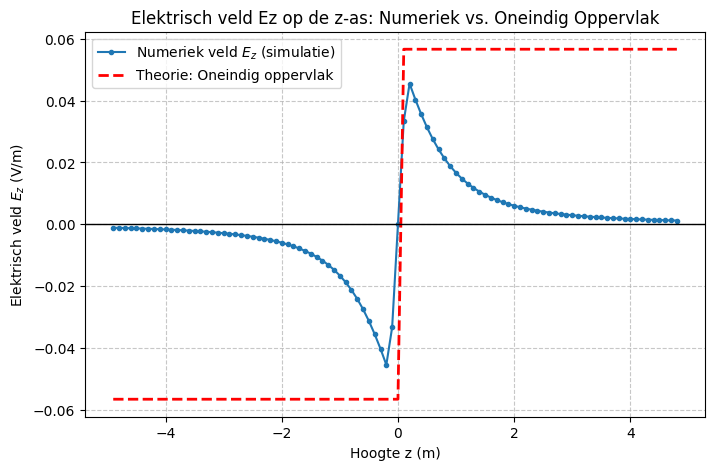

In [10]:


# 1. Bepaal de index waar de r-as 0 is (de centrale as)
idx_r_zero = np.argmin(np.abs(r_for_E))

# 2. Bereken het theoretische elektrische veld voor een oneindig oppervlak
# De formule uit Griffiths Example 2.5 is E = sigma / (2 * eps0)
# Belangrijk: boven de schijf wijst het veld omhoog (+), eronder omlaag (-)
eps0 = const.epsilon_0
E_theo = sigma / (2 * eps0)

# We maken een array voor de theorie die dezelfde vorm heeft als z_for_E (evenveel waardes)
# np.sign(z_for_E) zorgt ervoor dat het veld positief is bij z > 0 en negatief bij z < 0 (maakt er plus 1 of min 1 van)
E_theo_plot = E_theo * np.sign(z_for_E)

# 3. Plotten van de resultaten
plt.figure(figsize=(8, 5))
plt.title("Elektrisch veld Ez op de z-as: Numeriek vs. Oneindig Oppervlak")

# Plot de numerieke data (Ez)
# We gebruiken Ez[:, idx_r_zero] om de kolom van de as te pakken
plt.plot(z_for_E, Ez[:, idx_r_zero], "o-", label="Numeriek veld $E_z$ (simulatie)", markersize=3)

# Plot de theoretische lijn (oneindig oppervlak)
plt.plot(z_for_E, E_theo_plot, "r--", label="Theorie: Oneindig oppervlak", linewidth=2)

# 4. Opmaak van de plot
plt.xlabel("Hoogte z (m)")
plt.ylabel("Elektrisch veld $E_z$ (V/m)")
plt.axhline(0, color='black', lw=1) # Voeg een nullijn toe voor de duidelijkheid
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Sla de plot op
plt.savefig("elektrisch_veld_z_as_vergelijking.png", dpi=300)

plt.show()
# Het is natuurlijk de helling van die potentiaal van net dat zie je ook door die rechte lijn bij rood
# want heeft natuulijk een constante helling en die andere volgt dan als je verder van 0 zit die 1/z^2 van de puntlading

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Het elektrische veld benadert dat van een oneindig geladen plaat wanneer de hoogte (z) heel dicht bij 0 zit. Dit komt doordat de schijf op die korte afstand het volledige 'gezichtsveld' vult, waardoor het veld uniform lijkt (alsof de lading overal oneindig doorloopt). Naarmate je verder van de schijf afgaat, begint de schijf zich steeds meer als een puntlading te gedragen. Hierdoor neemt de veldsterkte af met 1/z^2, waardoor de numerieke simulatie niet langer overeenkomt met de constante waarde van de oneindige-plaat-theorie.

2. 1e verschil: De rode lijn blijft constant terwijl de blauwe lijn terugbuigt.
   verklaring: De theorie gaat uit van een oneindige plaat terwijl in de werkelijkheid hij dat niet is en hij dus als een puntlading beschouwd word als je verder komt en dan dus die 1/z^2 volgt

   2e verschil: Bij z = 0 zie je dat de rooie lijn bijna recht omhoog gaat en die blauwe een hele schuine lijn geeft.
   verklaring: dit komt door de stapgrootte waarmee de computer berekent die gridstep als je die zou verkleinen zou die blauwe lijn ook schuiner lopen.

   3e verschil: De blauwe lijn blijft bij zijn maxima altijd lager en bij zijn minima altijd hoger dan de rooie lijn.
   verklaring: Dit komt doordat bij de echte plaat er aan de randen geen ladingen meer zijn waardoor de oneindige plaat altijd een grotere maxima en kleinere minima hebben. 

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

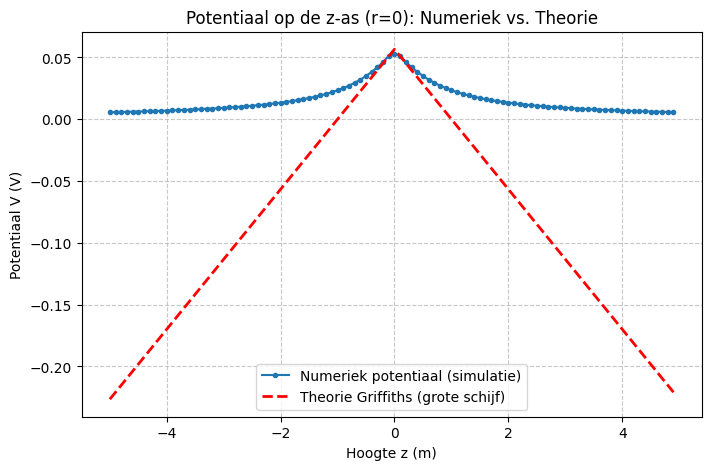

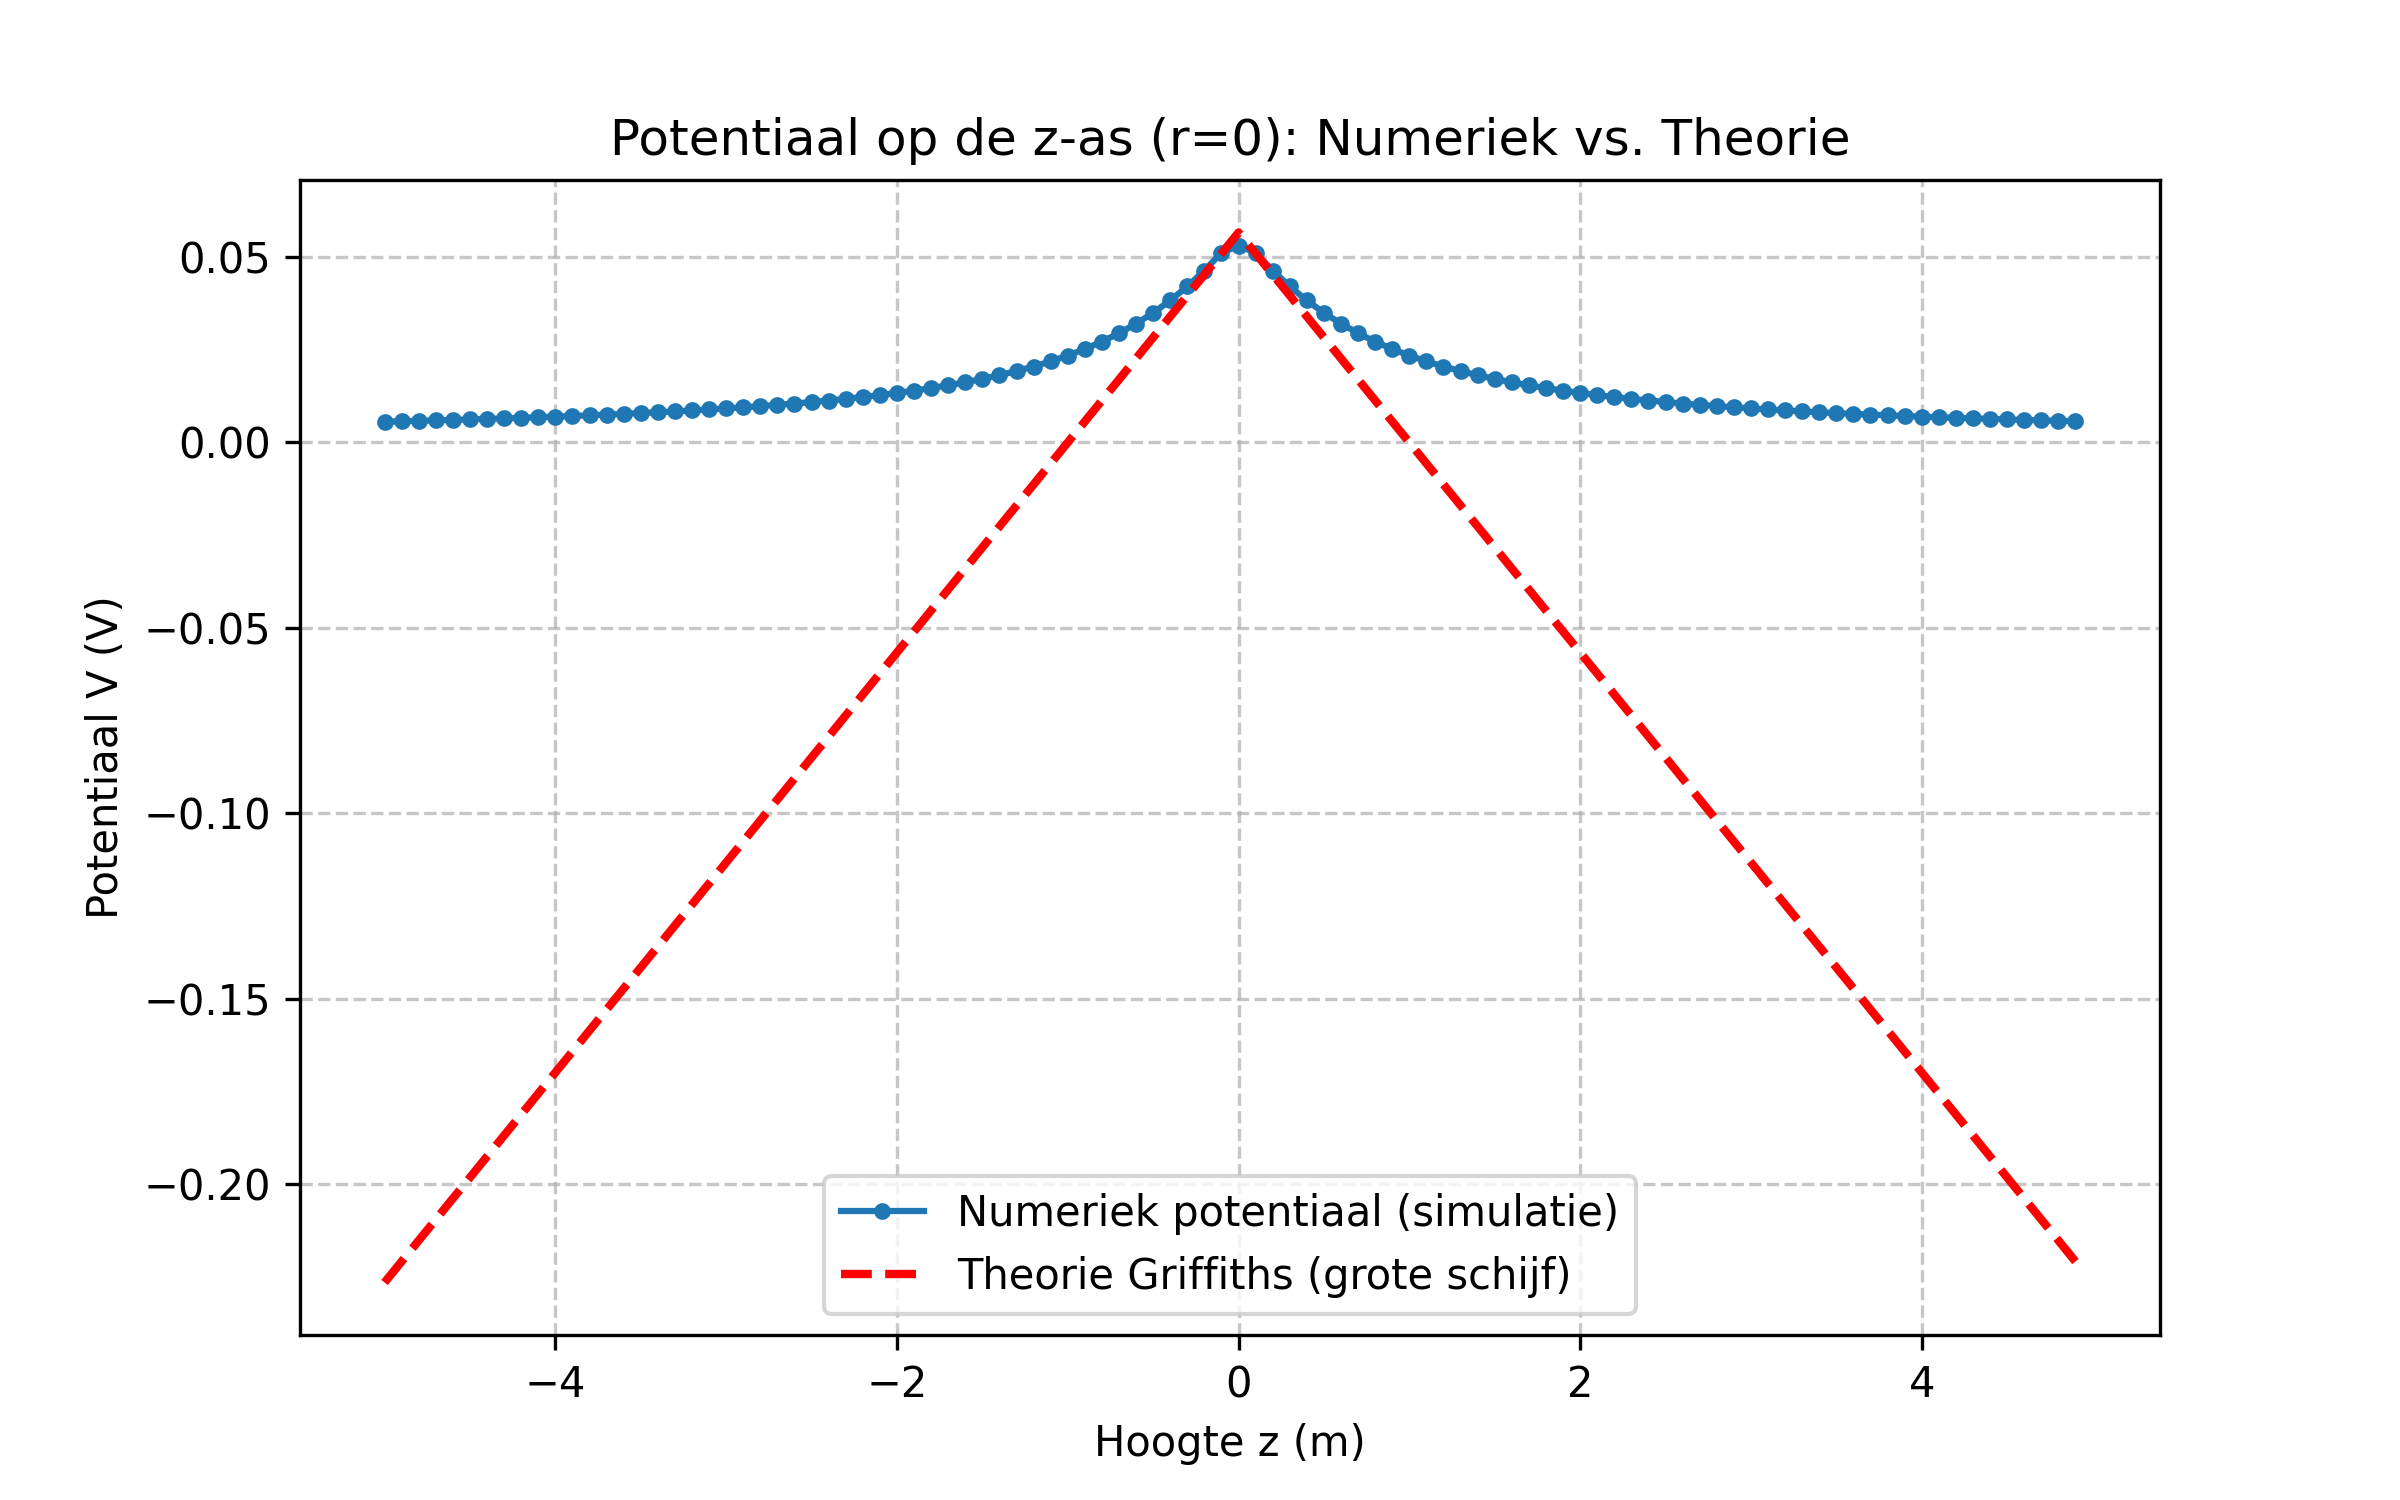

In [11]:
#dit is voor d ik heb gewoon de code gekopieerd aangezien je precies hetzelfde nodig hebt
# 1. Bepaal de index waar de r-as 0 is (het centrum van de schijf)
# We zoeken de kolom in de V-matrix die overeenkomt met r = 0.
idx_r_zero = np.argmin(np.abs(r))

# 2. Bereken het theoretische potentiaal op de z-as volgens Griffiths (R >> z)
# De formule is V = (sigma / (2 * eps0)) * (R - |z|)
# We gebruiken np.abs(z) voor de absolute waarde van z.
eps0 = const.epsilon_0
V_theo_z = (sigma / (2 * eps0)) * (disk_radius - np.abs(z))

# 3. Plotten van de resultaten
plt.figure(figsize=(8, 5))
plt.title("Potentiaal op de z-as (r=0): Numeriek vs. Theorie")

# Plot de numerieke data: we selecteren alle z-waarden voor de kolom r=0
# V[:, idx_r_zero] betekent: neem alle rijen (z) van kolom idx_r_zero (r=0)
plt.plot(z, V[:, idx_r_zero], "o-", label="Numeriek potentiaal (simulatie)", markersize=3)

# Plot de theoretische lijn voor een grote schijf
plt.plot(z, V_theo_z, "r--", label="Theorie Griffiths (grote schijf)", linewidth=2)


plt.xlabel("Hoogte z (m)")
plt.ylabel("Potentiaal V (V)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Sla de plot op als een afbeelding
plt.savefig("potentiaal_z_asf_vergelijking.png", dpi=300)

plt.show()
# De grafiek laat zien dat de benadering voor een oneindig grote schijf (rood) alleen goed overeenkomt in het gebied direct rondom de schijf waar z 0 is. 
# De numerieke simulatie (blauw) is beter op grotere afstanden aangezien deze het correcte verval van 1/z laat zien omdat het op grote afstand als een puntlading beschouwd kan worden. 
# Bij de rooie krijg je zelfs een negatieve potentiaal op een gegeven moment maar dat kan natuurlijk niet.
# Dit is een goeie benadering die formule als je dicht bij z=0 zit wat ook te zien is in de grafiek.
display(Image("potentiaal_z_as_vergelijking.png"))



De verschillen.
Je ziet dat als de straal kleiner word er nog een kleiner gebied word beschreven door die formule van de oneindige plaat en hij dus op een kleiner gebied overeenkomt.


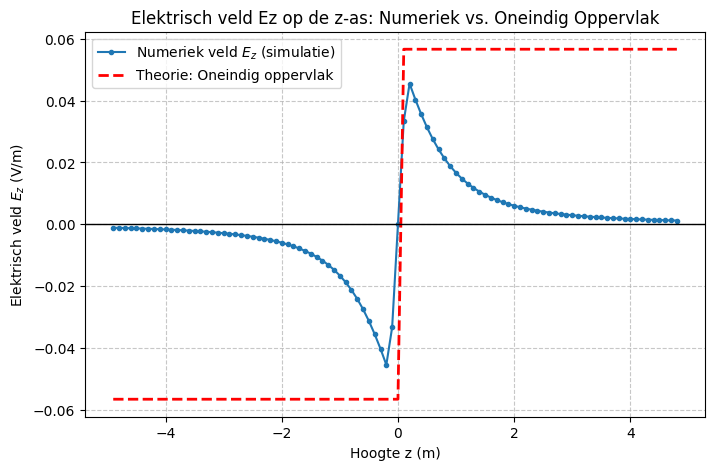

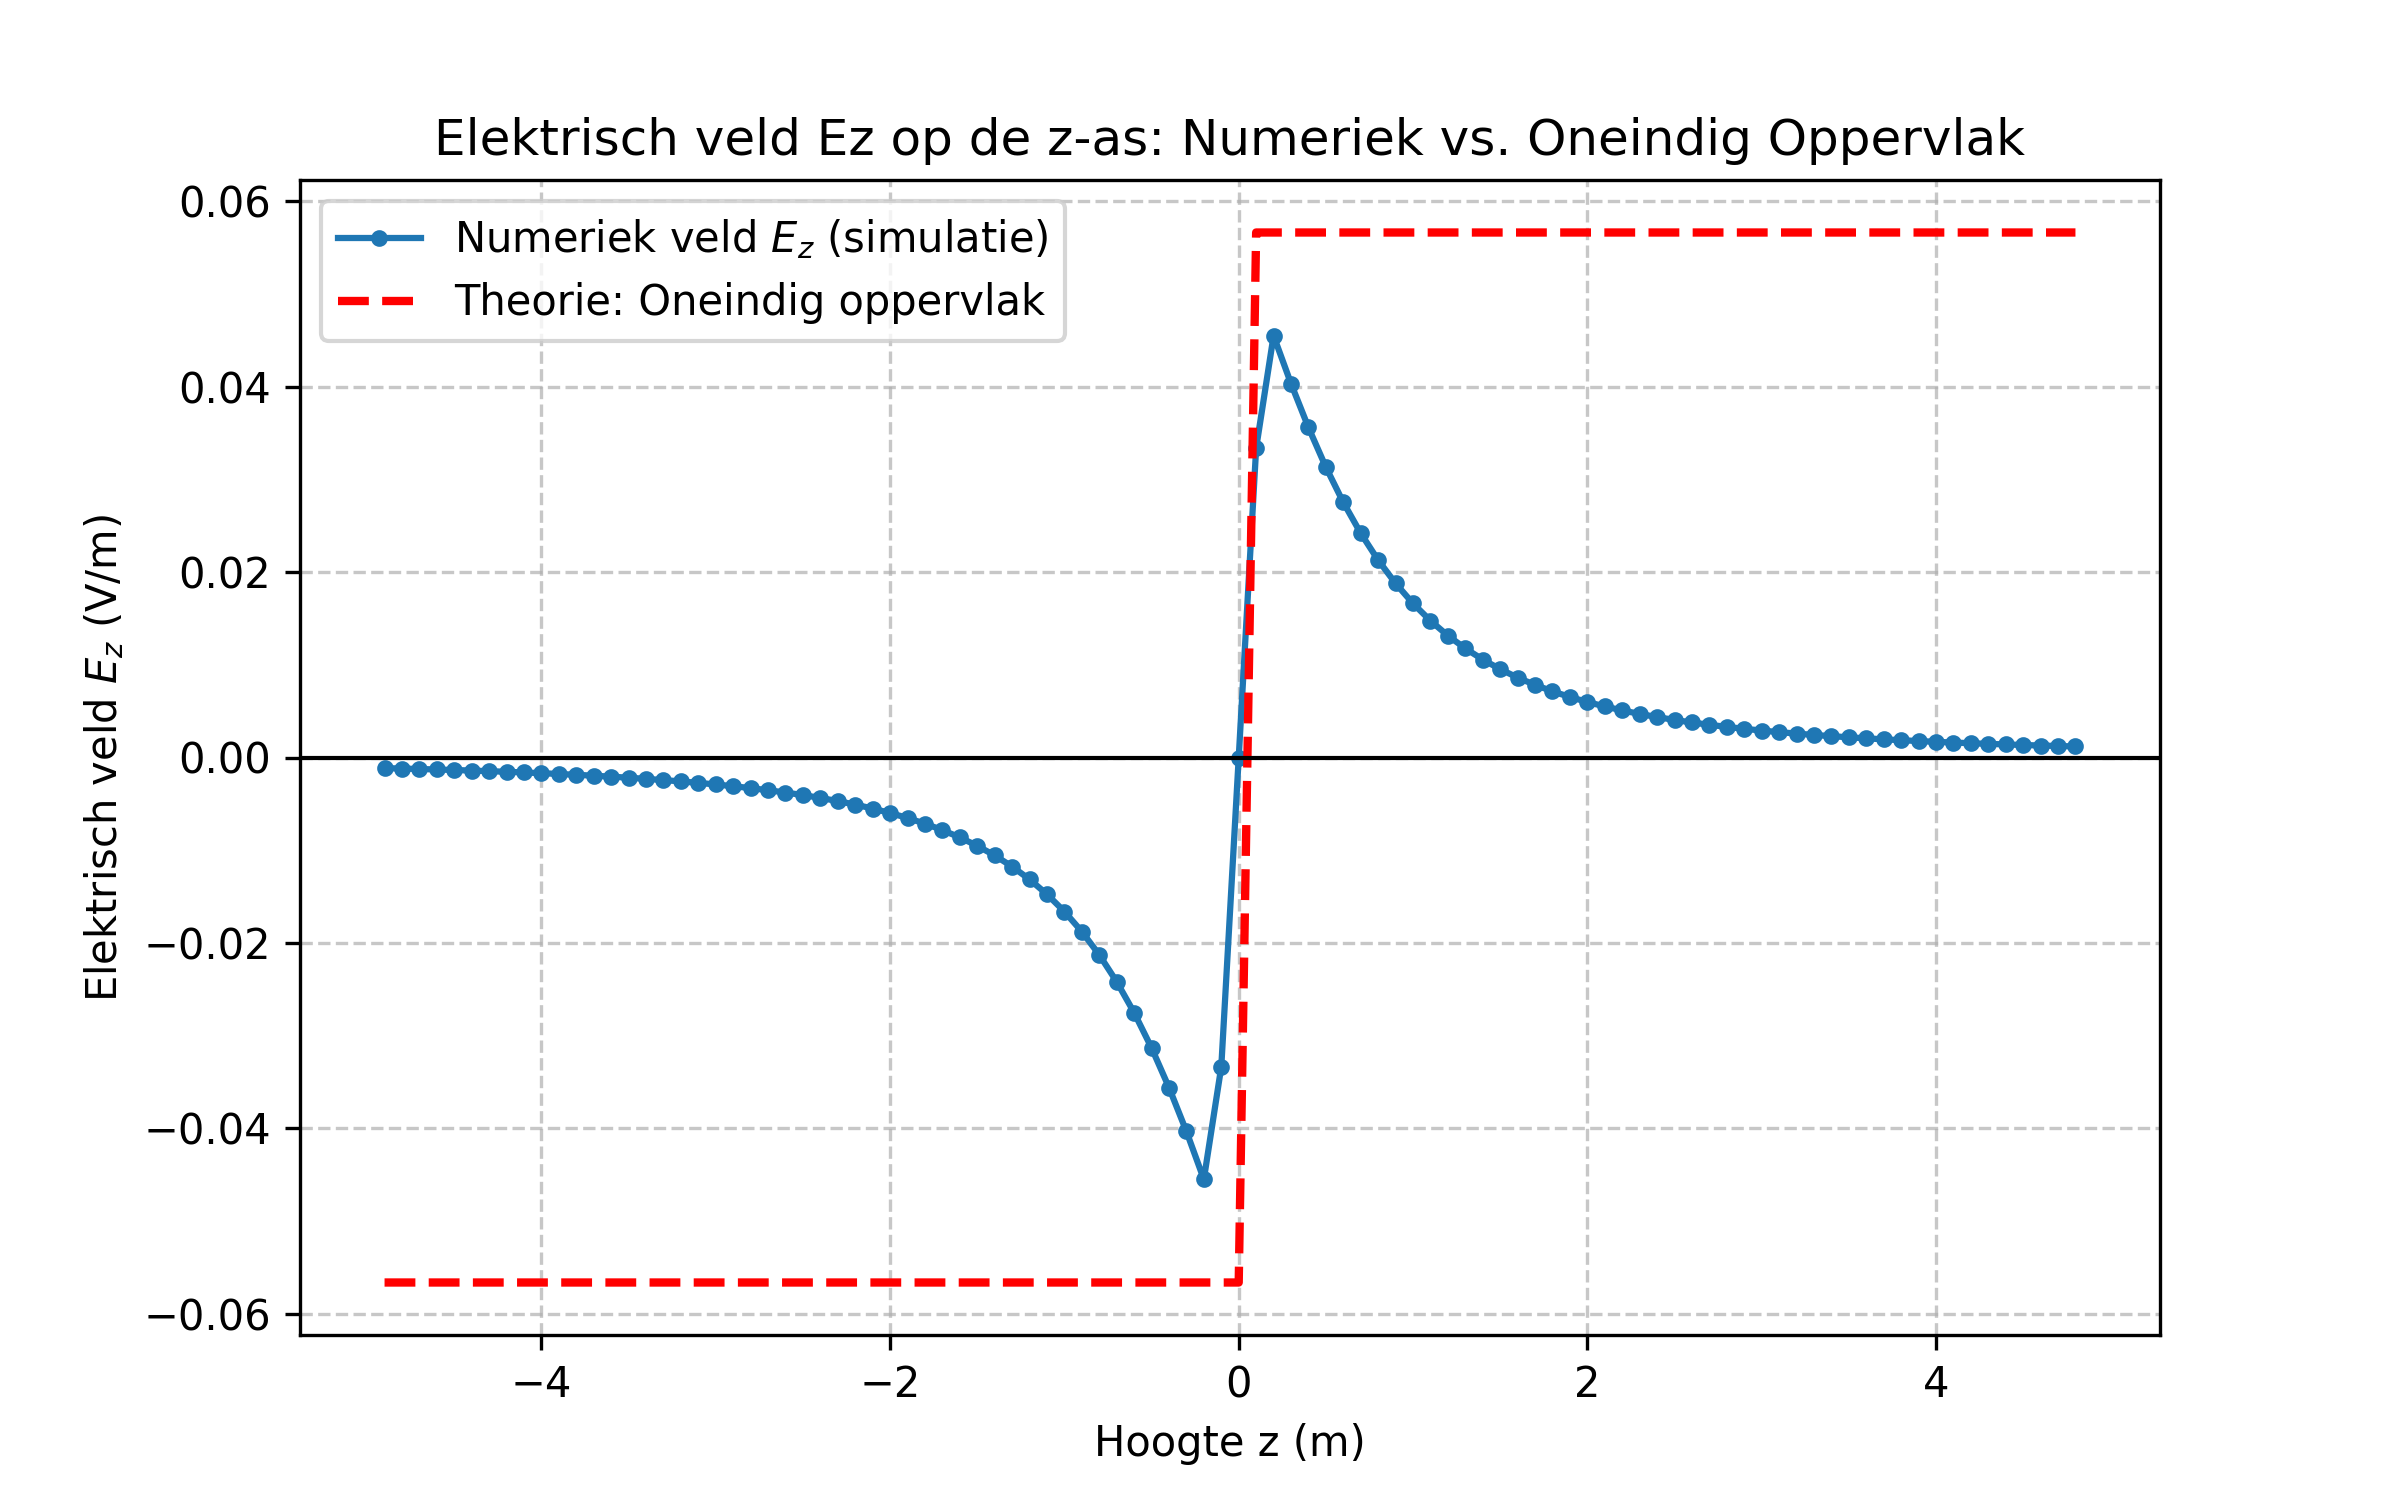

In [12]:


# 1. Bepaal de index waar de r-as 0 is (de centrale as)
idx_r_zero = np.argmin(np.abs(r_for_E))

# 2. Bereken het theoretische elektrische veld voor een oneindig oppervlak
# De formule uit Griffiths Example 2.5 is E = sigma / (2 * eps0)
# Belangrijk: boven de schijf wijst het veld omhoog (+), eronder omlaag (-)
eps0 = const.epsilon_0
E_theo = sigma / (2 * eps0)

# We maken een array voor de theorie die dezelfde vorm heeft als z_for_E (evenveel waardes)
# np.sign(z_for_E) zorgt ervoor dat het veld positief is bij z > 0 en negatief bij z < 0 (maakt er plus 1 of min 1 van)
E_theo_plot = E_theo * np.sign(z_for_E)

# 3. Plotten van de resultaten
plt.figure(figsize=(8, 5))
plt.title("Elektrisch veld Ez op de z-as: Numeriek vs. Oneindig Oppervlak")

# Plot de numerieke data (Ez)
# We gebruiken Ez[:, idx_r_zero] om de kolom van de as te pakken
plt.plot(z_for_E, Ez[:, idx_r_zero], "o-", label="Numeriek veld $E_z$ (simulatie)", markersize=3)

# Plot de theoretische lijn (oneindig oppervlak)
plt.plot(z_for_E, E_theo_plot, "r--", label="Theorie: Oneindig oppervlak", linewidth=2)

# 4. Opmaak van de plot
plt.xlabel("Hoogte z (m)")
plt.ylabel("Elektrisch veld $E_z$ (V/m)")
plt.axhline(0, color='black', lw=1) # Voeg een nullijn toe voor de duidelijkheid
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Sla de plot op
plt.savefig("elektrisch_veld_z_asf_vergelijking.png", dpi=300)

plt.show()
display(Image("elektrisch_veld_z_as_vergelijking.png"))

De verschillen.
Je ziet dat de de maxima en minima van blauw kleiner zijn als de straal kleiner is. Wat je ook ziet is dat de blauwe lijn veel sneller naar 0 afbuigt bij degene waar de straal kleiner is.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h
De voorwaarde is dat het veld van de schijf 10% van het veld van een oneindige plaat bedraagt:$$E_{schijf} = 0,1 \cdot E_{plaat}$$Omdat de constante factor aan beide kanten wegvalt, houden we deze vergelijking over:$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0,1$$Berekening van z:Herschrijven:$$0,9 = \frac{z}{\sqrt{R^2 + z^2}}$$Kwadrateren:$$0,81 = \frac{z^2}{R^2 + z^2}$$Kruislings vermenigvuldigen:$$0,81R^2 + 0,81z^2 = z^2$$Z isoleren:$$0,81R^2 = 0,19z^2$$Oplossen voor z:$$z = \sqrt{\frac{0,81}{0,19}} R$$Eindresultaat:$$z \approx 2,065 R$$Voor een schijf met een straal van R = 3 m komt dit neer op een hoogte van:z ≈ 6,20 m  (voor de opmaak heb ik wel de hulp van ai gebruikt om dat zo netjes te krijgen)

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

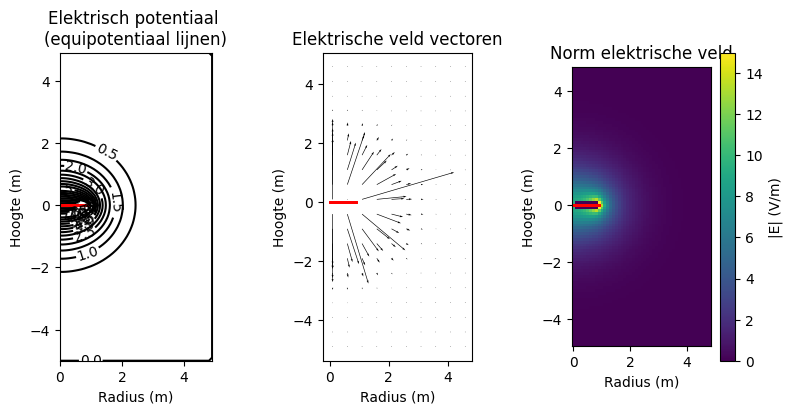

In [13]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)


# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

# """--------------------------------------------------------------------
# Veldberekening voor een geleidende schijf
# """
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

# """"---------------------------------------------------------
# Plot het berekende veld
# """
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

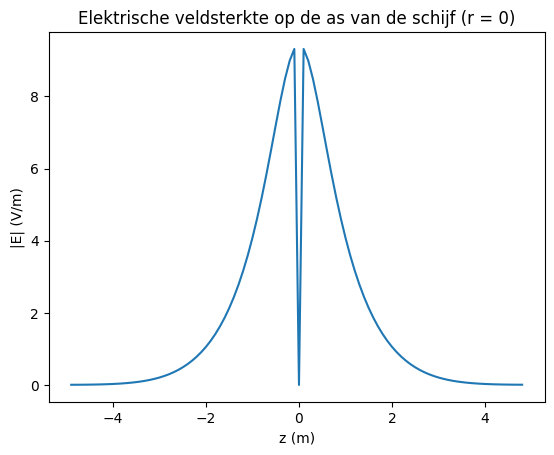

De norm van het elektrische veld vlak bij het midden van de schijf is: 4.068e-12 V/m


In [14]:
# index van r ≈ 0
idx_r_zero = np.argmin(np.abs(r_for_E))

# neem veld langs de as (r = 0)
E_axis = normE[:, idx_r_zero]

plt.figure()
plt.plot(z_for_E, E_axis)
plt.title("Elektrische veldsterkte op de as van de schijf (r = 0)")
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.show()

# index z ≈ schijfpositie
idx_z_disk = np.argmin(np.abs(z_for_E - z_pos_disk1))

E_center = normE[idx_z_disk, idx_r_zero]

print(f"De norm van het elektrische veld vlak bij het midden van de schijf is: {E_center:.3e} V/m")

# We bepalen eerst de index die overeenkomt met r ≈ 0 om de symmetrie-as van de schijf te selecteren.
# Vervolgens nemen we uit normE de kolom (of rij, afhankelijk van de array-oriëntatie) die hoort bij r = 0.
# Dit levert de elektrische veldsterkte langs de z-as van de schijf op.
# Daarna bepalen we het roosterpunt dat het dichtst bij de positie van de schijf (z = z_pos_disk1) ligt.
# Ten slotte lezen we daar de veldsterkte af om de waarde van het elektrische veld vlak bij het midden van de schijf te verkrijgen.



#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

1. Door middel van de formule: $\sigma = \epsilon_0*E$, kan de oppervlaktelading benaderd worden in het midden van de schijf. In deze formule zijn \epsilon_0 de permittiviteit van vacuum en E is het loodrechte veldcomponent (loodrecht op het oppervlak net buiten de geleider).

##### Antwoord 3b



In [15]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.

# index van r ≈ 0
idx_r_zero = np.argmin(np.abs(r_for_E))

# index van z net boven de schijf
idx_z_surface = np.argmin(np.abs(z_for_E - z_pos_disk1))

# neem Ez net buiten de geleider
Ez_surface = Ez[idx_z_surface, idx_r_zero]

# bereken oppervlakteladingsdichtheid
sigma_center = epsilon0 * abs(Ez_surface)

print("Benadering van de oppervlakteladingsdichtheid in het midden van de schijf:")
print(f"σ(0) ≈ {sigma_center:.3e} C/m²")


# We gebruiken de randvoorwaarde voor een geleider: σ = ε0 * E_normaal (net buiten het oppervlak).
# Uit vraag 3a hebben we het elektrische veld langs de as bepaald.
# In vraag 3b hebben we daaruit σ(0) in het midden van de schijf berekend.
# Nu gebruiken we deze benadering om de totale lading op de schijf te schatten.
# Hiervoor vermenigvuldigen we de (benaderde) oppervlakteladingsdichtheid met het oppervlak van de schijf.


Benadering van de oppervlakteladingsdichtheid in het midden van de schijf:
σ(0) ≈ 3.602e-23 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Benadering van de totale lading op de schijf:
Q ≈ 1.132e-22 C


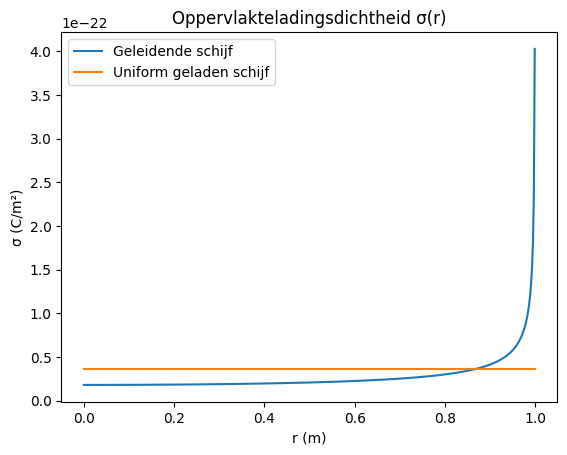

In [16]:
Q_totaal = sigma_center * np.pi * disk_radius**2

print("Benadering van de totale lading op de schijf:")
print(f"Q ≈ {Q_totaal:.3e} C")

# Gebruik eerder berekende totale lading
Q = Q_totaal
R = disk_radius

# r-waarden tussen 0 en R
r_vals = np.linspace(0, R*0.999, 500)

# Geleidende schijf
sigma_geleider = Q / (2 * np.pi * R * np.sqrt(R**2 - r_vals**2))

# Uniforme schijf
sigma_uniform = Q / (np.pi * R**2)
sigma_uniform_array = np.ones_like(r_vals) * sigma_uniform

# Plot
plt.figure()
plt.plot(r_vals, sigma_geleider, label="Geleidende schijf")
plt.plot(r_vals, sigma_uniform_array, label="Uniform geladen schijf")
plt.xlabel("r (m)")
plt.ylabel("σ (C/m²)")
plt.title("Oppervlakteladingsdichtheid σ(r)")
plt.legend()
plt.show()


#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [17]:
# We zoeken het maximale elektrische veld in de hele gesimuleerde ruimte
E_max = np.max(normE)  # normE is de 2D array met veldsterkte |E|
# Vind de index van het maximum in de 2D array
idx_max = np.unravel_index(np.argmax(normE), normE.shape)

# Haal de coördinaten eruit
z_max = z_for_E[idx_max[0]]  # z-richting
r_max = r_for_E[idx_max[1]]  # r-richting

# Index van r ≈ 0 (as)
idx_r_zero = np.argmin(np.abs(r_for_E))

# Index van z ≈ schijfpositie
idx_z_disk = np.argmin(np.abs(z_for_E - z_pos_disk1))

# Elektrisch veld in het midden van de schijf
E_center = normE[idx_z_disk, idx_r_zero]

# Hoeveel keer hoger is het maximum?
E_ratio = E_max / E_center

print(f"Maximum elektrische veld: |E|max = {E_max:.3e} V/m")
print(f"Locatie van het maximum: r = {r_max:.3f} m, z = {z_max:.3f} m")
print(f"Elektrisch veld in het midden van de schijf: |E|center = {E_center:.3e} V/m")
print(f"Het maximum is {E_ratio:.2f} keer hoger dan het veld in het midden van de schijf")


Maximum elektrische veld: |E|max = 1.499e+01 V/m
Locatie van het maximum: r = 1.000 m, z = 0.100 m
Elektrisch veld in het midden van de schijf: |E|center = 4.068e-12 V/m
Het maximum is 3684174326443.72 keer hoger dan het veld in het midden van de schijf


##### Antwoord 3d.5

Het maximum elektrische veld ontstaat aan de rand van de geleidende schijf, niet in het midden.

Dit komt door de randvorming (edge effect) bij geleiders: ladingsdichtheid hoopt zich op bij scherpe randen of aflopende oppervlakken.

Hierdoor is het veld lokaal veel sterker dan in het centrum van de schijf, waar de ladingsdichtheid lager is.

Dit fenomeen is typisch voor geleidende oppervlakken en verklaart bijvoorbeeld waarom vonkvorming eerder bij randen optreedt.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

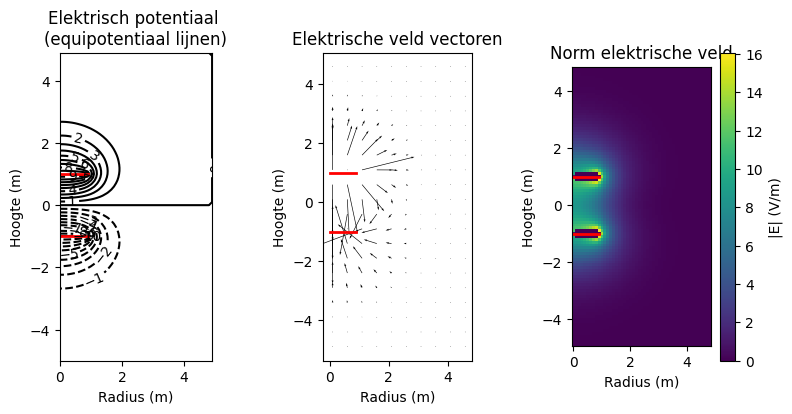

In [18]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


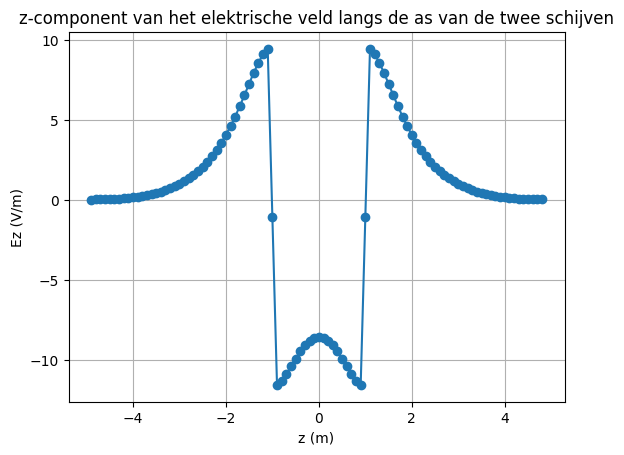

In [19]:
r_nul = np.argmin(np.abs(r_for_E))  # dichtstbijzijnde index bij r=0
Ez_as = Ez[:, r_nul]  # Ez langs z-richting bij r = 0

plt.figure()
plt.plot(z_for_E, Ez_as, "o-")
plt.title("z-component van het elektrische veld langs de as van de twee schijven")
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.grid(True)
plt.show()


#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b
1. Theoretisch elektrisch veld:

als we de twee parralelle schijven op potentiaal V_1 en V_2 zien op een afstand d en de platen als perfect vlak benaderen, zal het potenitaal lineair varieren tussen de platen volgens de formule: $$V(z) = V_1 + \frac{V_2-V_2}{d}*(z-z_1)$$ en het potentiaal wordt gegeven door het negatieve gradiënt van het potentiaal, wat blijkt uit de formule: $$E_z = -\frac{dV}{dz}=\frac{V_1-V_2}{d}$$
uit de bovenstaande formules volgt dat het veld tussen de twee platen zowel constant als loodrecht op het plaat oppervlak moet staan en dat het veld van de positieve vaan de negatieve plaat beweegt.


2. Numeriek berekend elektrisch veld:

Uit de simulatie van de twee platen langs de symmetrie-as $(r = 0)$ blijkt dat het $z$-component van het elektrische veld vrijwel constant is tussen de platen, zoals theoretisch verwacht. Net bij de platenranden ontstaan kleine pieken door rand- of *edge-effects*, veroorzaakt door de eindige afmetingen van de schijven. Buiten de platen neemt het veld snel af tot bijna nul. Het numerieke resultaat bevestigt dus de theoretische verwachting, met kleine afwijkingen door discretisatie en het feit dat de schijven geen oneindige oppervlakken zijn.


3. Vergelijking met een enkele geleidende schijf:

Bij een enkele schijf op potentiaal $V_1$ is het elektrische veld in het centrum hoog vlakbij de schijf, maar neemt het snel af met toenemende afstand. Het veld is niet uniform en geconcentreerd rond de schijf. Door twee schijven met tegengestelde potentiaal te plaatsen, ontstaat daarentegen een bijna uniform elektrisch veld tussen de platen. De maximale veldsterkte in het midden van de twee schijven ligt veel lager dan de piek bij een enkele schijf.  

Het voordeel van deze configuratie is dat het een gecontroleerd, uniform elektrisch veld creëert, met verminderde randpieken en een stabielere omgeving voor experimenten of toepassingen zoals parallelle plaatcondensatoren.


#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
#gegevens:
epsilon_0 = 8.854e-12  # F/m
disk_radius = 3        # m
V1 = 10                # V
V2 = -10               # V
d = abs(V1 - V2)/((V1 - V2)/(2))  # afstand tussen platen (2 m)

# Oppervlakte schijf
import numpy as np
A = np.pi * disk_radius**2

# Verwachte elektrische veld en oppervlakteladingsdichtheid
E_expected = (V1 - V2)/d
sigma_expected = epsilon_0 * E_expected

# Totale lading
Q_expected = sigma_expected * A

# Capaciteit
C_expected = Q_expected / (V1 - V2)

print("Verwachte waarden voor twee parallelle geleidende platen:")
print(f"Oppervlakteladingsdichtheid σ = {sigma_expected:.3e} C/m²")
print(f"Totale lading op één plaat Q = {Q_expected:.3e} C")
print(f"Capaciteit van de condensator C = {C_expected:.3e} F")


Verwachte waarden voor twee parallelle geleidende platen:
Oppervlakteladingsdichtheid σ = 8.854e-11 C/m²
Totale lading op één plaat Q = 2.503e-09 C
Capaciteit van de condensator C = 1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d
1. oppervlaktelading aan de buitenkant van de schijf:

Voor een ideale geleider geldt dat het elektrische veld binnenin nul is. Dit betekent dat alle ladingen zich verdelen zodat ze het interne veld opheffen. Voor de twee parallelle schijven op tegengestelde potentiaal betekent dit dat de netto oppervlakteladingsdichtheid aan de buitenkant van de platen praktisch nul is. De ladingen bevinden zich aan de binnenkant van de platen, waar ze elkaar beïnvloeden en een veld ertussen creëren. Hierdoor ontstaat aan de buitenkant van de condensator geen elektrisch veld; de velden van de twee platen heffen elkaar grotendeels op.

2. elektrische veld nabij het oppervlak:

Direct buiten het oppervlakvan een geleider wijst het elektrische veld altijd loodrecht op het oppervlak, en de grootte van dit veld wordt bepaald door de oppervlakteladingsdichtheid $\sigma$ en de permittiviteit van het medium volgens: $E = \frac{\sigma}{\epsilon_0}$. Binnen de geleider is het veld nul, wat betekent dat het hele effect van de ladingen geconcentreerd is op het oppervlak. Deze concentratie van lading aan de binnenkant van de platen en het loodrechte veld aan het oppervlak verklaart waarom het elektrische veld tussen de platen uniform kan worden benaderd en waarom het veld buiten de condensator verwaarloosbaar klein is.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [21]:
# gegevens:
epsilon0 = 8.854e-12  # F/m
V1 = 10               # bovenste plaat
V2 = -10              # onderste plaat
d = 2                 # afstand tussen de platen (m)

# Oppervlakteladingsdichtheid onderste plaat (binnenkant)
sigma_inside = epsilon0 * (V1 - V2)/d

# Elektrisch veld net boven de onderste plaat (binnenkant)
E_above = sigma_inside / epsilon0  # V/m

# Elektrisch veld net onder de onderste plaat (buitenkant)
E_below = 0     # volgens theorie is buitenkant veld bijna nul
sigma_below = 0  # ladingsdichtheid onderkant

# Ladingsdichtheid bovenkant (onderste plaat)
sigma_above = sigma_inside

print(f"""Elektrisch veld en oppervlakteladingsdichtheid bij de onderste plaat:
1. E_z net onder de onderste plaat: {E_below} V/m
2. σ onderkant van de onderste plaat: {sigma_below} C/m²
3. E_z net boven de onderste plaat: {E_above} V/m
4. σ bovenkant van de onderste plaat: {sigma_above:.3e} C/m²""")


Elektrisch veld en oppervlakteladingsdichtheid bij de onderste plaat:
1. E_z net onder de onderste plaat: 0 V/m
2. σ onderkant van de onderste plaat: 0 C/m²
3. E_z net boven de onderste plaat: 10.0 V/m
4. σ bovenkant van de onderste plaat: 8.854e-11 C/m²


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

Uit de resultaten van 4d en 4e blijkt dat de ladingsdichtheid op de platen niet uniform is. De lading bevindt zich vrijwel volledig op de naar elkaar toegekeerde zijden, maar zelfs daar is de verdeling niet vlak: aan de randen treedt een duidelijke toename van 
𝜎
 op door rand­effecten. De aanname in 4c van een uniforme ladingsverdeling is dus lokaal onjuist, maar de totale lading blijft vergelijkbaar zolang de platen groot zijn ten opzichte van de afstand.

De capaciteit wordt hierdoor nauwelijks beïnvloed. De parallelplaatformule: $C = \frac{\epsilon_0*A}{d}$ is een goede benadering wanneer rand­effecten klein zijn, omdat het veld tussen de platen dan bijna uniform blijft en de totale lading nauwelijks afwijkt van de ideale situatie.

Wanneer je de afstand tussen de platen verkleint, wordt het veld tussen de platen sterker en gelijkmatiger, en neemt de ladingsdichtheid op de binnenzijden toe. De capaciteit stijgt dan volgens verwachting, want $C$ omgekeer proportioneel blijft aan $d$. dit komt, omdat er meer lading nodig is om hetzelfde potentiaalverschil vast te houden.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [22]:
import math

# Natuurkundige constante: permittiviteit van het vacuüm
EPSILON_0 = 8.854187e-12 

def vlakkeplaat(A, d, epsilon_r=1):
    """
    Berekent de capaciteit van een vlakke plaat condensator.
    Input: A (m^2), d (m), epsilon_r (dimensieloos)
    Output: C (Farad)
    """
    # De formule rechtstreeks vertaald naar code
    C = (epsilon_r * EPSILON_0 * A) / d
    return C

def cilinder(L, R1, R2, epsilon_r=1):
    """
    Berekent de capaciteit van een cilinder condensator.
    Input: L (m), R1 (m), R2 (m), epsilon_r (dimensieloos)
    Output: C (Farad)
    """
    # We gebruiken hier de exacte formule met de logaritme
    # math.log() in Python is de natuurlijke logaritme (ln)
    teller = 2 * math.pi * epsilon_r * EPSILON_0 * L
    noemer = math.log(R2 / R1)
    
    C = teller / noemer
    return C
# Test vlakke plaat
print(f"Capaciteit Plaat: {vlakkeplaat(0.01, 0.001):.2e} F")

# Test cilinder
print(f"Capaciteit Cilinder: {cilinder(0.1, 0.01, 0.011):.2e} F")

#Natuurkunde erachter is ff handig om het zo te hebben:
#     - We nemen aan dat het elektrisch veld (E) tussen de platen constant is (E = V/d).
#     - Dit mag alleen als de afstand 'd' veel kleiner is dan de afmetingen van de plaat.
#     - De capaciteit (C) is de verhouding tussen de opgeslagen lading (Q) en de spanning (V).
#     - Formule: C = (epsilon_0 * epsilon_r * A) / d

# Natuurkunde erachter is ff handig om het zo te hebben:
#     - Bij een cilinder is het elektrisch veld niet constant, maar neemt het af met 1/r
#       naarmate je verder van de as komt (radiaal veld).
#     - Om de spanning (V) te vinden, integreren we het veld tussen de twee radii (R1 en R2).
#     - De natuurlijke logaritme (ln) in de formule is het directe resultaat van die integratie.
#     - Formule: C = (2 * pi * epsilon * L) / ln(R2 / R1)
# epsilon_r (relatieve permittiviteit) geeft aan hoeveel 'makkelijker' het materiaal 
# tussen de platen lading opslaat vergeleken met vacuüm. Voor lucht is dit bijna 1.


Capaciteit Plaat: 8.85e-11 F
Capaciteit Cilinder: 5.84e-11 F


#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [23]:
# --- Dit staat al bij 5.1 (Niet dubbel typen!) ---
import math
EPSILON_0 = 8.854e-12 

# def vlakkeplaat(A, d, epsilon_r=1): ...
# def cilinder(L, R1, R2, epsilon_r=1): ...

# --- VRAAG 5b: NIEUWE BEREKENINGEN ---

# Voorbereiding parameters (Alles naar meters!)
oppervlak_A = 0.1 * 0.1  # 10x10 cm = 0.01 m^2
afstand_d   = 0.001       # 1 mm = 0.001 m

L_cil = 0.1              # 10 cm = 0.1 m
R1    = 0.0045           # 4.5 mm
R2    = 0.0050           # 5.0 mm

print("--- Resultaten Vraag 5b ---")

# 1 & 2. Lucht (epsilon_r is standaard 1)
c1 = vlakkeplaat(oppervlak_A, afstand_d)
c2 = cilinder(L_cil, R1, R2)
print(f"1. Vlakke plaat (Lucht): {c1:.2e} F")
print(f"2. Cilinder (Lucht):     {c2:.2e} F")

# 3. Afstand verdubbeld (d wordt 0.002m, R2 wordt 0.0055m)
print(f"3. Afstand x2 - Plaat: {vlakkeplaat(oppervlak_A, 0.002):.2e} F")
print(f"3. Afstand x2 - Cil:   {cilinder(L_cil, R1, 0.0055):.2e} F")

# 4. Gevuld met water (epsilon_r = 80)
print(f"4. Water - Plaat: {vlakkeplaat(oppervlak_A, afstand_d, 80):.2e} F")
print(f"4. Water - Cil:   {cilinder(L_cil, R1, R2, 80):.2e} F")

# 5. Gevuld met PVC (epsilon_r = 3)
print(f"5. PVC - Plaat: {vlakkeplaat(oppervlak_A, afstand_d, 3):.2e} F")
print(f"5. PVC - Cil:   {cilinder(L_cil, R1, R2, 3):.2e} F")

# Is gewoon de formules invullen met de waardes van boven en dan kijken wat er gebeurt als je die waardes aanpast.

--- Resultaten Vraag 5b ---
1. Vlakke plaat (Lucht): 8.85e-11 F
2. Cilinder (Lucht):     5.28e-11 F
3. Afstand x2 - Plaat: 4.43e-11 F
3. Afstand x2 - Cil:   2.77e-11 F
4. Water - Plaat: 7.08e-09 F
4. Water - Cil:   4.22e-09 F
5. PVC - Plaat: 2.66e-10 F
5. PVC - Cil:   1.58e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [24]:
import math

# --- VRAAG 5.1 CONSTANTEN & FUNCTIES ---
# EPSILON_0 bepaalt hoe 'moeilijk' een veld door vacuüm gaat.
EPSILON_0 = 8.854e-12 
C_doel = 1e-6 # 1 microFarad (10^-6 Farad)

# --- BEREKENING 1: CILINDER CONDENSATOR ---
# NATUURKUNDE ACHTER DE LENGTE:
# 1. We gebruiken de omgeschreven formule: L = (C * ln(R2/R1)) / (2 * pi * eps0).
# 2. De ln(R2/R1) term komt voort uit het feit dat het elektrisch veld in een 
#    cilinder sterker is bij de binnenkern dan bij de buitenmantel.
# 3. De enorme lengte (kilometers!) komt doordat we lucht gebruiken (epsilon_r = 1).
#    Lucht is een slechte 'opslaghelper' vergeleken met vaste stoffen.

R1 = 0.0025 # Straal binnen (meters)
R2 = 0.0030 # Straal buiten (meters)

lengte_cilinder = (C_doel * math.log(R2 / R1)) / (2 * math.pi * EPSILON_0)

# --- BEREKENING 2: VLAKKE PLAAT CONDENSATOR ---
# 1. Voor een vlakke plaat geldt C = (eps0 * A) / d. Dus A = (C * d) / eps0.
# 2. Omdat we een capaciteit van 1uF willen (best veel) en een afstand van 0.5mm 
#    (best groot voor een condensator), hebben we een enorm oppervlak (m2) nodig.
# 3. De factor 10^-12 in eps0 onder de deelstreep zorgt ervoor dat de 
#    uitkomst in de ordegrootte van kilometers terechtkomt.

d = 0.0005       # Afstand tussen platen (meters)
breedte = 0.006  # Breedte van de strip (meters)

# Berekening direct naar lengte_plaat zonder de losse variabele 'oppervlak_A'
lengte_plaat = (C_doel * d) / (EPSILON_0 * breedte)

# --- OUTPUT ---
print("--- Resultaten Analyse 1 uF ---")
print(f"Benodigde lengte cilinder: {lengte_cilinder:.2f} meter")
print(f"Benodigde lengte plaat:    {lengte_plaat:.2f} meter")

# in de volgende vraag staat nog even goed uitgelegd waarom die afstanden zo groot zijn.


--- Resultaten Analyse 1 uF ---
Benodigde lengte cilinder: 3277.32 meter
Benodigde lengte plaat:    9411.94 meter


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. 
De berekende lengtes van enkele kilometers zijn in de praktijk totaal niet realistisch voor een losse component. Een condensator van die omvang zou nooit in een elektronisch apparaat passen en bovendien kampen met een enorme interne weerstand door de extreem lange geleiders. De uitkomst laat vooral zien dat de eenheid Farad gigantisch is en dat lucht, in combinatie met een relatief grote plaatafstand, een zeer inefficiënte manier is om lading op te slaan. De berekening dient dus puur om aan te tonen dat de theoretische "ideale" luchtcondensator niet bruikbaar is voor hoge capaciteiten in kleine ruimtes.

2.
Fabrikanten lossen dit ruimtegebrek op door de variabelen in de capaciteitsformule flink aan te passen. Ten eerste wordt de afstand tussen de geleiders verkleind van millimeters naar nanometers, vaak door gebruik te maken van hele dunne oxidelaagjes. Daarnaast wordt lucht vervangen door diëlektrische materialen zoals keramiek of polymeren met een zeer hoge relatieve permittiviteit, wat de capaciteit duizenden malen vergroot. Tot slot wordt het benodigde oppervlak compact gemaakt door de lange lagen folie strak op te rollen tot een kleine cilinder of ze honderden keren op te stapelen in een minuscuul blokje. Of door het effectieve oppervlak te vergroten

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [25]:
# --- NIEUWE BEREKENINGEN VRAAG 5e ---

# Gegeven en schattingen
v_kmh = 70
v_ms = v_kmh / 3.6             # Omrekenen naar m/s
V_voltage = 10000              # 10 kV = 10.000 V
d_afstand = 0.001              # 1 mm = 0.001 m
EPS_WATER = 80                 # Relatieve permittiviteit van water

# 1. Schatting massa treintje
# Een karretje voor 6 personen + het frame zelf:
massa_trein = 1500             # Schatting: 1500 kg

# 2. Energieberekening (E_kinetisch = 0.5 * m * v^2)
energie_nodig = 0.5 * massa_trein * (v_ms**2)

# 3. Capaciteit berekenen (C = 2 * E / V^2)
# Omgeschreven van E = 0.5 * C * V^2
C_totaal = (2 * energie_nodig) / (V_voltage**2)

# 4. Oppervlakte vlakke plaat berekenen
# We gebruiken de formule C = (eps0 * eps_r * A) / d 
# Omgeschreven: A = (C * d) / (eps0 * eps_r)
oppervlak_achtbaan = (C_totaal * d_afstand) / (EPSILON_0 * EPS_WATER)

# 5. netjes even uitprinten
print("-" * 40)
print("--- ANALYSE FORMULE X CONDENSATOR ---")
print(f"1. Geschatte massa trein:      {massa_trein} kg")
print(f"2. Totale kinetische energie:  {energie_nodig:.2f} Joule")
print(f"3. Benodigde capaciteit:       {C_totaal:.4f} Farad")
print(f"4. Benodigd oppervlak (water): {oppervlak_achtbaan:.2f} m^2")
print("-" * 40)

----------------------------------------
--- ANALYSE FORMULE X CONDENSATOR ---
1. Geschatte massa trein:      1500 kg
2. Totale kinetische energie:  283564.81 Joule
3. Benodigde capaciteit:       0.0057 Farad
4. Benodigd oppervlak (water): 8006.69 m^2
----------------------------------------


##### Antwoorden 5e
Hoewel een oppervlakte van enkele tientallen vierkante meters veel realistischer is dan de kilometers uit de vorige opdrachten. Blijft een enkele vlakke plaat met watervulling onpraktisch voor een pretpark, vanwege het enorme gewicht en de risico's bij 10 kV. In de werkelijkheid wordt dit opgelost door gebruik te maken van supercondensatoren, deze bevatten materialen zoals actieve koolstof met een extreem poreuze structuur, waardoor het effectieve oppervlak op microscopisch niveau miljoenen malen groter wordt zonder dat de buitenkant groeit. Door deze gigantische oppervlakken strak op te rollen of in honderden lagen te stapelen, kan de energie voor een lancering compact worden opgeslagen in een niet al te grote kast.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

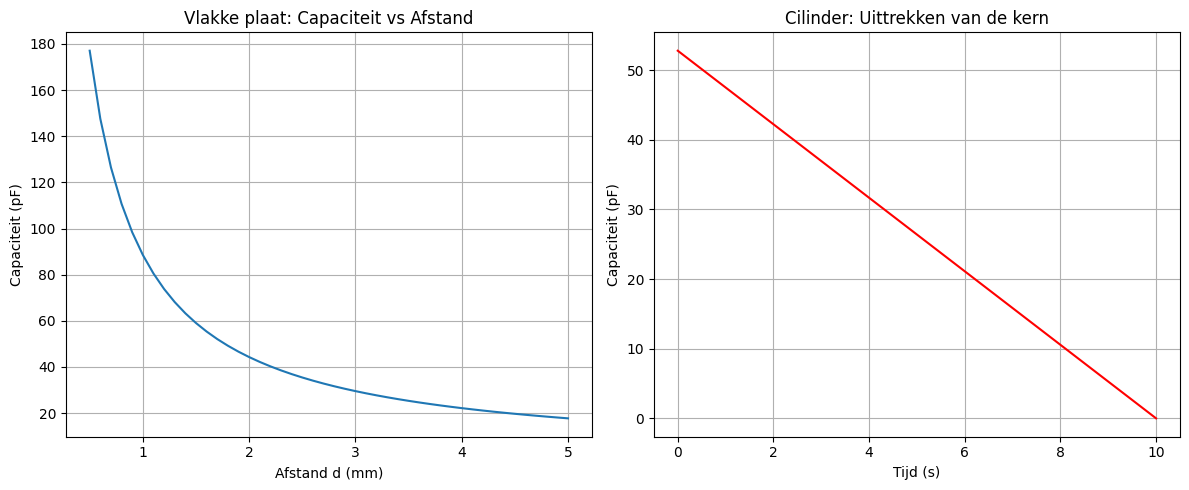

In [26]:
import matplotlib.pyplot as plt

# --- (Bestaande functies van 5.1 worden hier gebruikt) ---
# EPSILON_0 = 8.854e-12 
# def vlakkeplaat(A, d, epsilon_r=1): ...
# def cilinder(L, R1, R2, epsilon_r=1): ...

# --- 1. VLAKKE PLAAT: Variabele afstand ---
oppervlak_A = 0.1 * 0.1
afstanden = [d / 10000 for d in range(5, 51)] # van 0.5mm tot 5mm in stappen
capaciteiten_plaat = [vlakkeplaat(oppervlak_A, d) for d in afstanden]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([d * 1000 for d in afstanden], [c * 1e12 for c in capaciteiten_plaat])
plt.title("Vlakke plaat: Capaciteit vs Afstand")
plt.xlabel("Afstand d (mm)")
plt.ylabel("Capaciteit (pF)")
plt.grid(True)

# 2 CILINDER: Uittrekken van de kern 
# Gegeven: binnendiameter 9mm (R1=4.5), buitendiameter 10mm (R2=5.0)
R1, R2 = 0.0045, 0.0050
L_start = 0.1
tijd = list(range(11)) # 0 tot 10 seconden

# De lengte L neemt lineair af van 10cm naar 0cm in 10 seconden
lengtes = [L_start * (1 - t/10) for t in tijd]
capaciteiten_cil = [cilinder(L, R1, R2) for L in lengtes]

plt.subplot(1, 2, 2)
plt.plot(tijd, [c * 1e12 for c in capaciteiten_cil], color='red')
plt.title("Cilinder: Uittrekken van de kern")
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit (pF)")
plt.grid(True)

plt.tight_layout()
plt.show()

#Bij de vlakke plaat condensator is er sprake van een omgekeerd evenredig verband tussen de afstand en de capaciteit. 
# Dit komt doordat de afstand $d$ in de noemer van de formule $C = \frac{\varepsilon_0 \varepsilon_r A}{d}$ staat. 
# In de natuurkunde betekent dit dat naarmate de platen dichter bij elkaar komen, de elektrische aantrekkingskracht tussen de ladingen op de verschillende platen toeneemt, 
# waardoor er veel meer lading opgeslagen kan worden. 
# In de grafiek zie je dan ook een hyperbool. De capaciteit neemt wel snel af naarmate de afstand groter wordt. 
# Dit maakt een vlakke plaat zeer geschikt als precisiesensor voor microscopische verplaatsingen.
# In tegenstelling tot de vlakke plaat vertoont de cilindercondensator een lineair verband wanneer de binnenste kern eruit wordt getrokken. 
# Omdat de lengte $L$ in de teller van de formule $C = \frac{2 \pi \varepsilon_0 \varepsilon_r L}{\ln(R_2 / R_1)}$ staat, is de capaciteit direct afhankelijk van de overlap tussen de twee cilinders. 
# Natuurkundig gezien verklein je simpelweg het effectieve oppervlak waar het elektrisch veld zich kan vormen. 
# Als de kern met een constante snelheid wordt bewogen, daalt de capaciteit in een rechte lijn. Dit gedrag is erg nuttig voor sensoren die over een groter bereik een voorspelbare en gelijkmatige meting moeten geven.
# Zoals bij het meten van de stand van een schuifregelaar of een vloeistofniveau.

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [27]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [28]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons| 1.12   |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

 vraag 1:

 De wet van Gauss: $\oint \vec{D} \cdot d\vec{A} = {Q_{\text{vrij}}}$.

 ook geldt dat: $\frac{Q_(tot)}{\epsilon_0} = \oint \vec{E} \cdot d\vec{A} = \int (\nabla \cdot \vec{E}) dv$.    
voor de ladingsdichtheid geldt: $\rho_{\text{tot}} = \rho_{\text{vrij}} + \rho_{\text{gebonden}}$.

vanuit de wet van Gauss voor het elektrische veld:$ \nabla \cdot \mathbf{E} = \frac{\rho_{\text{tot}}}{\varepsilon_0}$
en voor de gebonden elektronen geldt: $\rho_{\text{gebonden}} = - \nabla \cdot \mathbf{P}$

het hierbovenstaande samenvoegen geeft: $\nabla \cdot \mathbf{E} = \frac{\rho_{\text{vrij}} - \nabla \cdot \mathbf{P}}{\varepsilon_0}$.
tot slot komt hier het volgende uit: $\mathbf{D} = \varepsilon_0 \mathbf{E} + \mathbf{P}$.

vraag 2: 

Voor een niet-lineair diëlektricum geldt dat de polarisatie een functie is van het elektrisch veld, dus:
$\mathbf{P} = \varepsilon_0 (\chi_1 \mathbf{E} + \chi_2 \mathbf{E}^2)$.

Invullen in de gevonden uitdrukking van D geeft:
$\mathbf{D} = \varepsilon_0 \mathbf{E} + \varepsilon_0 (\chi_1 \mathbf{E} + \chi_2 \mathbf{E}^2)$.

Factoriseren:
$\mathbf{D} = \varepsilon_0 (1+\chi_1)\mathbf{E} + \varepsilon_0 \chi_2 \mathbf{E}^2$.

Dit geeft de volgende kwadratische vergelijking in $\mathbf{E}$: 
$\varepsilon_0 \chi_2 E^2 + \varepsilon_0 (1+\chi_1)E - D = 0$.

Oplossen geeft:
$E = \frac{-\varepsilon_0 (1+\chi_1) + \sqrt{[\varepsilon_0 (1+\chi_1)]^2 + 4\varepsilon_0 \chi_2 D}}{2\varepsilon_0 \chi_2}$.

Voor $\chi_2 = 0$ reduceert dit tot het lineaire geval:

$E = \frac{D}{\varepsilon_0 (1+\chi_1)}$.


#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [13]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

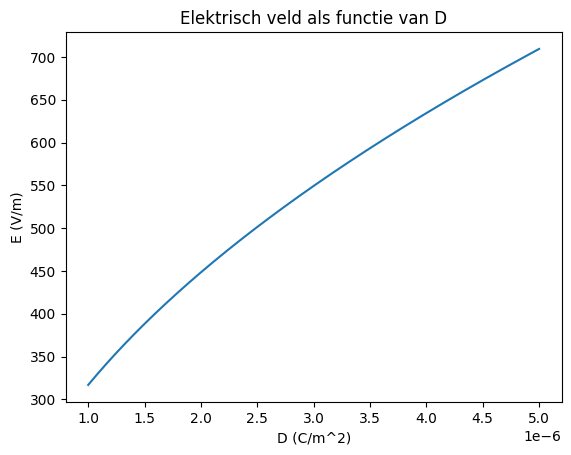

In [14]:
epsilon_0 = 8.854e-12

# Materiaalconstanten (voorbeeld: spons)
chi1 = 0.5
chi2 = 1.12   # gegeven in tabel

# D-veld (uit fysieke ontwerpopdracht)
D = np.linspace(1e-6, 5e-6, 200)

# Analytische oplossing voor E(D)
E = (-(1+chi1) + np.sqrt((1+chi1)**2 + 4*chi2*D/epsilon_0)) / (2*chi2)

plt.plot(D, E)
plt.xlabel("D (C/m^2)")
plt.ylabel("E (V/m)")
plt.title("Elektrisch veld als functie van D")
plt.show()


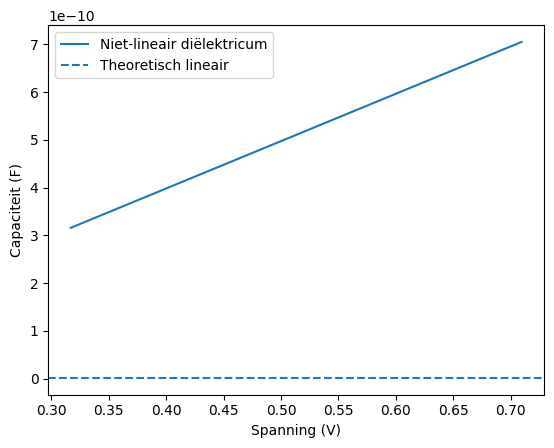

In [15]:
A = 1e-4     # m^2
d = 1e-3     # afstand tussen platen

V = E * d
C_nonlinear = (D * A) / V

plt.plot(V, C_nonlinear, label="Niet-lineair diëlektricum")

# Theoretisch lineair model
epsilon_r = 1 + chi1
C_theoretical = epsilon_0 * epsilon_r * A / d
plt.axhline(C_theoretical, linestyle='--', label="Theoretisch lineair")

plt.xlabel("Spanning (V)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()


#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*